# Notebook 1 — Embeddings na prática

Objetivos:

- gerar embeddings densos para frases em português
- medir similaridade semântica com cosseno
- visualizar agrupamentos em 2D
- discutir trade-off entre compressão e qualidade

Execute de cima para baixo. Por padrão o notebook usa um modelo local via `sentence-transformers`.


## Provider

Opções:

- `EMBEDDING_PROVIDER=local` (default): roda sem API externa
- `EMBEDDING_PROVIDER=openai`: usa OpenAI se `OPENAI_API_KEY` estiver definido

Se a chave não existir, o notebook cai automaticamente para o provider local.


In [27]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

cwd = Path.cwd()
candidates = [
    cwd,
    cwd.parent,
    cwd / "aulao-3-embeddings-e-vector-db",
    cwd.parent / "aulao-3-embeddings-e-vector-db",
]
if cwd.name == "notebooks":
    candidates.insert(0, cwd.parent)
PROJECT_ROOT = next(
    (
        path
        for path in candidates
        if (path / ".env").exists() or (path / "data" / "rag_docs").exists()
    ),
    cwd.parent if cwd.name == "notebooks" else cwd,
)
load_dotenv(PROJECT_ROOT / ".env", override=True)


True

In [28]:
EMBEDDING_PROVIDER = "openai" if os.getenv("OPENAI_API_KEY") else "local"
OPENAI_MODEL = os.getenv("OPENAI_EMBEDDING_MODEL", "text-embedding-3-small")
LOCAL_MODEL = os.getenv(
    "LOCAL_EMBEDDING_MODEL",
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
)

if EMBEDDING_PROVIDER == "openai" and not os.getenv("OPENAI_API_KEY"):
    print("OPENAI_API_KEY não encontrada. Voltando para provider local.")
    EMBEDDING_PROVIDER = "local"

if EMBEDDING_PROVIDER == "openai":
    from openai import OpenAI

    client = OpenAI()

    def embed_texts(texts, dimensions=None):
        kwargs = {"model": OPENAI_MODEL, "input": texts}
        if dimensions is not None:
            kwargs["dimensions"] = dimensions
        response = client.embeddings.create(**kwargs)
        return np.array([item.embedding for item in response.data], dtype=np.float32)

else:
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(LOCAL_MODEL)

    def embed_texts(texts, dimensions=None):
        if dimensions is not None:
            raise ValueError("O provider local deste notebook não recebe dimensões customizadas.")
        vectors = model.encode(texts, normalize_embeddings=True)
        return np.array(vectors, dtype=np.float32)

{
    "provider": EMBEDDING_PROVIDER,
    "openai_model": OPENAI_MODEL if EMBEDDING_PROVIDER == "openai" else None,
    "local_model": LOCAL_MODEL if EMBEDDING_PROVIDER == "local" else None,
}


{'provider': 'openai',
 'openai_model': 'text-embedding-3-small',
 'local_model': None}

## Amostras de texto

A ideia aqui não é benchmark, e sim intuição:

- frases semanticamente próximas devem cair perto
- frases de domínios diferentes devem se separar
- embeddings não dependem de palavras idênticas para captar similaridade


In [29]:
samples = [
    {"texto": "cachorro grande", "grupo": "pets"},
    {"texto": "cão de grande porte", "grupo": "pets"},
    {"texto": "filhote de labrador brincando", "grupo": "pets"},
    {"texto": "gato dormindo no sofá", "grupo": "pets"},
    {"texto": "avião comercial decolando", "grupo": "aviacao"},
    {"texto": "aeronave inicia o pouso", "grupo": "aviacao"},
    {"texto": "piloto alinhou na pista", "grupo": "aviacao"},
    {"texto": "torre autorizou a aterrissagem", "grupo": "aviacao"},
    {"texto": "pedido de home office", "grupo": "rh"},
    {"texto": "política de trabalho remoto", "grupo": "rh"},
    {"texto": "reembolso da viagem corporativa", "grupo": "rh"},
    {"texto": "benefício de internet para trabalho remoto", "grupo": "rh"},
    {"texto": "compra de software aprovada pelo diretor", "grupo": "financeiro"},
    {"texto": "pagamento da fatura corporativa", "grupo": "financeiro"},
    {"texto": "renovação anual do contrato SaaS", "grupo": "financeiro"},
    {"texto": "incidente de segurança crítico", "grupo": "seguranca"},
    {"texto": "rotação emergencial de credenciais", "grupo": "seguranca"},
    {"texto": "vazamento de dados pessoais", "grupo": "seguranca"},
]

df = pd.DataFrame(samples)
df


,texto,grupo
0,cachorro grande,pets
1,cão de grande porte,pets
2,filhote de labrador brincando,pets
3,gato dormindo no sofá,pets
4,avião comercial decolando,aviacao
5,aeronave inicia o pouso,aviacao
6,piloto alinhou na pista,aviacao
7,torre autorizou a aterrissagem,aviacao
8,pedido de home office,rh
9,política de trabalho remoto,rh


In [30]:
embeddings = embed_texts(df["texto"].tolist())

print("Shape:", embeddings.shape)
print("Primeiras 8 dimensões do primeiro vetor:")
print(np.round(embeddings[0][:8], 4))


Shape: (18, 1536)
Primeiras 8 dimensões do primeiro vetor:
[ 0.0514 -0.0443  0.0088  0.0142 -0.027   0.0099 -0.0036  0.0238]


In [31]:
lookup = dict(zip(df["texto"], embeddings))

pairs = [
    ("cachorro grande", "cão de grande porte"),
    ("cachorro grande", "avião comercial decolando"),
    ("pedido de home office", "política de trabalho remoto"),
    ("reembolso da viagem corporativa", "pagamento da fatura corporativa"),
    ("incidente de segurança crítico", "rotação emergencial de credenciais"),
]

pair_scores = []
for left, right in pairs:
    score = cosine_similarity([lookup[left]], [lookup[right]])[0, 0]
    pair_scores.append(
        {
            "texto_a": left,
            "texto_b": right,
            "similaridade_cosseno": round(float(score), 4),
        }
    )

pd.DataFrame(pair_scores).sort_values("similaridade_cosseno", ascending=False)


,texto_a,texto_b,similaridade_cosseno
0,cachorro grande,cão de grande porte,0.7973
3,reembolso da viagem corporativa,pagamento da fatura corporativa,0.5859
2,pedido de home office,política de trabalho remoto,0.5474
4,incidente de segurança crítico,rotação emergencial de credenciais,0.4501
1,cachorro grande,avião comercial decolando,0.2365


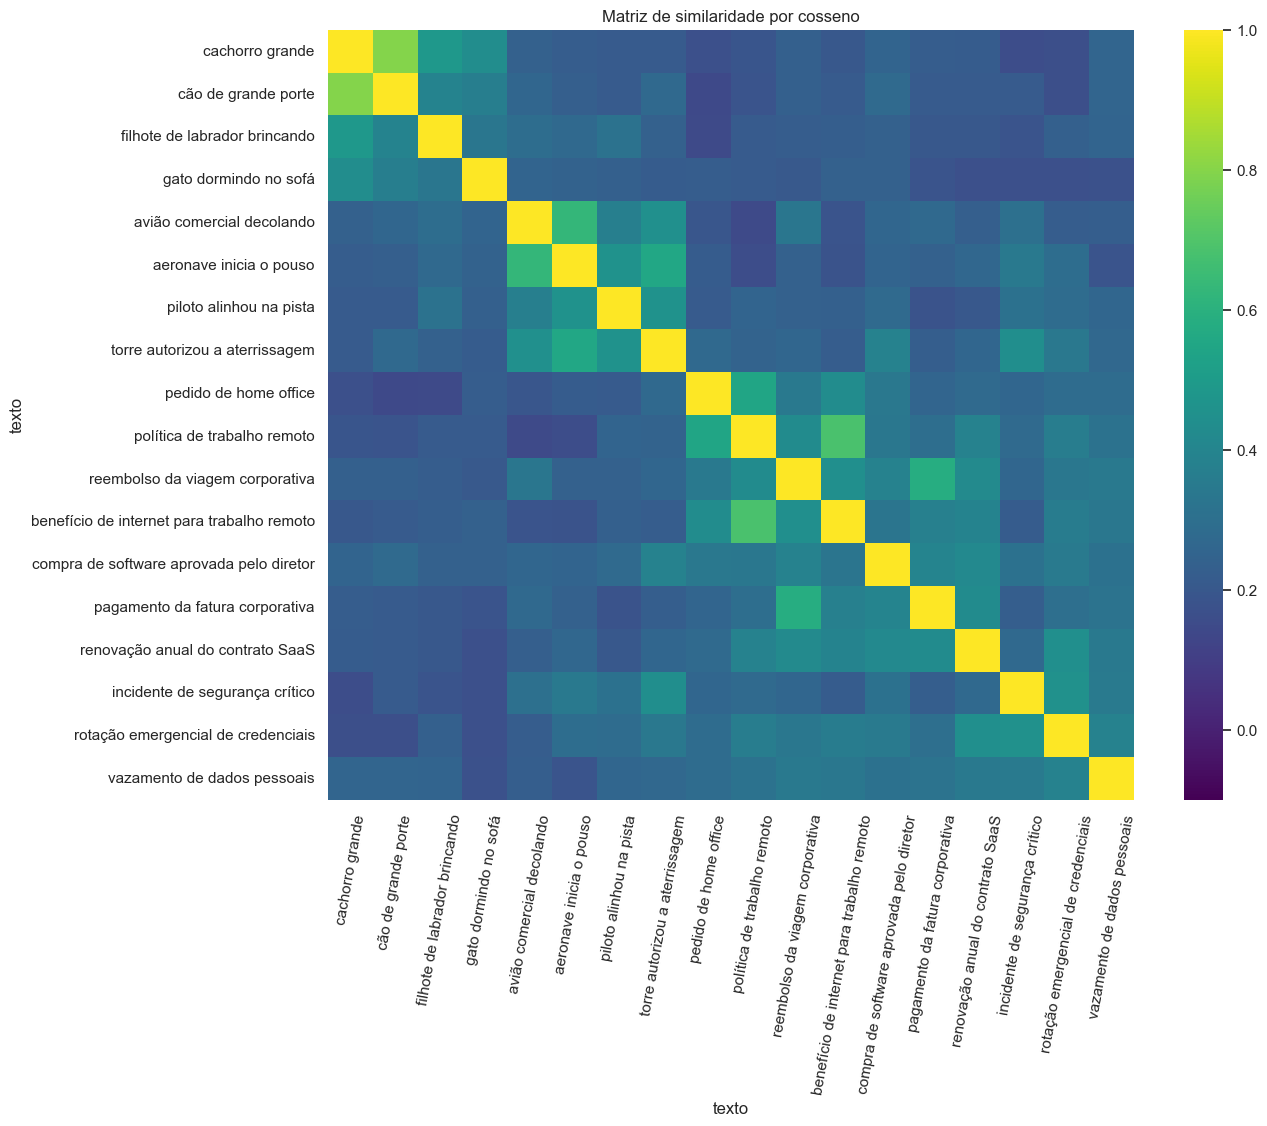

In [32]:
sim_matrix = cosine_similarity(embeddings)
sim_df = pd.DataFrame(sim_matrix, index=df["texto"], columns=df["texto"])

plt.figure(figsize=(13, 10))
sns.heatmap(sim_df, cmap="viridis", vmin=-0.1, vmax=1.0)
plt.title("Matriz de similaridade por cosseno")
plt.xticks(rotation=80)
plt.yticks(rotation=0)
plt.show()


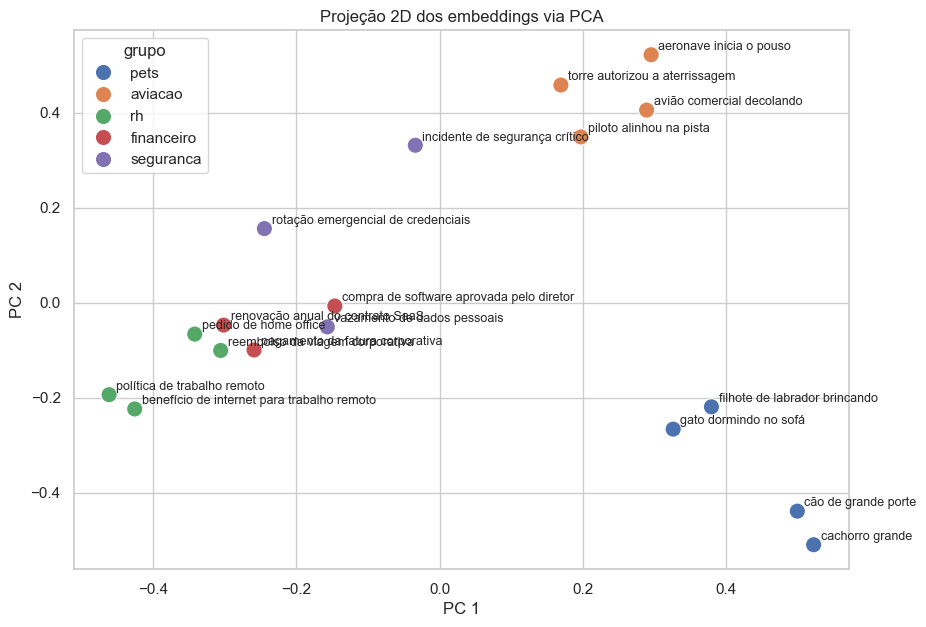

In [33]:
coords = PCA(n_components=2, random_state=42).fit_transform(embeddings)
plot_df = df.assign(x=coords[:, 0], y=coords[:, 1])

plt.figure(figsize=(10, 7))
sns.scatterplot(data=plot_df, x="x", y="y", hue="grupo", s=140)

for _, row in plot_df.iterrows():
    plt.text(row["x"] + 0.01, row["y"] + 0.01, row["texto"], fontsize=9)

plt.title("Projeção 2D dos embeddings via PCA")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


## Compressão de dimensão

Aqui a ideia é didática: comprimimos os vetores com PCA e medimos quanto da vizinhança original foi preservada.

Isso **não é** o mesmo que Matryoshka embeddings, mas ajuda a mostrar o trade-off entre footprint e fidelidade de vizinhança.


In [34]:
def mean_topk_overlap(original_vectors, reduced_vectors, top_k=3):
    original_neighbors = np.argsort(-cosine_similarity(original_vectors), axis=1)[:, 1 : top_k + 1]
    reduced_neighbors = np.argsort(-cosine_similarity(reduced_vectors), axis=1)[:, 1 : top_k + 1]

    overlaps = []
    for left, right in zip(original_neighbors, reduced_neighbors):
        overlaps.append(len(set(left).intersection(set(right))) / top_k)
    return float(np.mean(overlaps))


rows = [
    {
        "dimensoes": embeddings.shape[1],
        "variancia_explicada": 1.0,
        "overlap_top3": 1.0,
    }
]

for dims in [2, 4, 8, 12]:
    pca = PCA(n_components=dims, random_state=42)
    reduced = pca.fit_transform(embeddings)
    rows.append(
        {
            "dimensoes": dims,
            "variancia_explicada": round(float(pca.explained_variance_ratio_.sum()), 4),
            "overlap_top3": round(mean_topk_overlap(embeddings, reduced, top_k=3), 4),
        }
    )

pd.DataFrame(rows)


,dimensoes,variancia_explicada,overlap_top3
0,1536,1.0000,1.0000
1,2,0.2873,0.6296
2,4,0.4551,0.9074
3,8,0.6872,0.8333
4,12,0.8650,0.9259
